## Setup

In [1]:
from typing import Any, Literal
from pathlib import Path
import json

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from pydantic import BaseModel, Field
from sglang import (
    function,
    system,
    user,
    assistant,
    gen,
    set_default_backend,
    RuntimeEndpoint,
)

from matplotlib import pyplot as plt

tqdm.pandas()  # load tqdm's pandas support
pd.set_option("display.max_colwidth", 400)

## Check if Humans agree among themselves

In [2]:
path = Path("eval-all/llm_judge_human_reference/human-csv")
all_people = (
    pd.concat(
        {
            "felix": pd.read_csv(path / "felix.csv", index_col=0),
            "matthias": pd.read_csv(path / "matthias.csv", index_col=0),
            "paul": pd.read_csv(path / "paul.csv", index_col=0),
        },
    )
    .reset_index()
    .rename(columns={"level_0": "person"})
    .drop(columns={"level_1"})
)
all_people.head()

,person,setting,model,mode,sample_id,question_id,action_sequence,textual_description,question_type,answer_type,question,answer_text,prediction_text,human_judge
0,felix,4.2.2,Llama 2 (8B),full,25275,0,"{'start': array([ 0., 4., 8., 12.], dtype=float32), 'end': array([ 4., 8., 12., 16.], dtype=float32), 'action': array(['sitting down', 'sitting down', 'sitting down',\n 'golfing (swinging a club)'], dtype=object), 'action_sentence': array(['The first activity the person is doing is sitting down',\n 'The person is engaging in sitting down',\n 'The activity sitting down can ...","The first activity the person is doing is sitting down. This action is starting at 0:0.0 and happens until 0:4.0, meaning the engagement in this is for 4.0 seconds. The person is engaging in sitting down from 0:4.0 to 0:8.0 (4.0 seconds total). The activity sitting down can be observed. This is happening from 0:8.0 to 0:12.0, which means for a total time of 4.0 seconds. The finishing action of...",comparison_counting_open,open,"Among the actions, which one shares the same frequency of occurrence as sitting down?",The correct answer is golfing (swinging a club).,sitting down,1
1,felix,4.2.2,Gemma 2 (2B),full,25247,2,"{'start': array([ 0., 4., 8., 12.], dtype=float32), 'end': array([ 4., 8., 12., 16.], dtype=float32), 'action': array(['bowing', 'bowing', 'kicking a ball', 'skipping rope'],\n dtype=object), 'action_sentence': array(['The person is starting off the sequence with bowing',\n 'The person is engaging in bowing',\n 'The activity kicking a ball can be observed',\n 'The las...","The person is starting off the sequence with bowing at timestamp 0:0.0 and ending at 0:4.0, resulting in a total time of 4.0 seconds. The person is engaging in bowing. This action is starting at 0:4.0 and happens until 0:8.0, meaning the engagement in this is for 4.0 seconds. The activity kicking a ball can be observed. It is starting at second 0:8.0 and continuing until 0:12.0, so the person ...",before_open,open,"Before engaging in kicking a ball, what happened some time previously?",Someone is bowing.,bowing,3
2,felix,4.2.1,Falcon 2 (11B),350,27520,1,"{'start': array([ 0., 4., 8., 12.], dtype=float32), 'end': array([ 4., 8., 12., 16.], dtype=float32), 'action': array(['running', 'sitting down', 'running', 'holding a baby'],\n dtype=object), 'action_sentence': array(['The person is starting off the sequence with running',\n 'The person is performing sitting down',\n 'The person is performing running',\n 'The person ...","The person is starting off the sequence with running. It is starting at second 0:0.0 and continuing until 0:4.0, so the person is doing this for 4.0 seconds. The person is performing sitting down from 0:4.0 to 0:8.0 (for 4.0 seconds). The person is performing running. This action is starting at 0:8.0 and happens until 0:12.0, meaning the engagement in this is for 4.0 seconds. The person is ter...",first_open,open,Which action did the person perform as the first action?,Someone is running.,"running, sitting down, and holding a baby.",1
3,felix,4.2.2,MVP,full,27562,1,"{'start': array([ 0., 4., 8., 12.], dtype=float32), 'end': array([ 4., 8., 12., 16.], dtype=float32), 'action': array(['drinking with the left hand', 'jumping once', 'running',\n 'drinking with the left hand'], dtype=object), 'action_sentence': array(['The first activity the person is doing is drinking with the left hand',\n 'The activity is jumping once',\n 'The activity ...","The first activity the person is doing is drinking with the left hand from 0:0.0 to 0:4.0 (for 4.0 seconds). The activity is jumping once. This action is starting at 0:4.0 and happens until 0:8.0, meaning the engagement in this is for 4.0 seconds. The activity running can be observed from 0:8.0 to 0:12.0 (4.0 seconds total). As a last action, the person is drinking with the left hand from 0:12...",interval_part_sequence_open,open,"From 1.756 until 6.515, what is the total number of distinct actions the person engages in?"

In [3]:
grouped = all_people.groupby(["sample_id", "question_id", "model", "setting", "mode"])
assert grouped.apply(lambda x: len(x) == 3).all()

agreement = grouped.apply(lambda x: x["human_judge"].nunique())
agreement.value_counts()

1    177
2     23
Name: count, dtype: int64

In [4]:
# 1 means all agree, 2 means two agree, 3 means all disagree
agreement.value_counts(normalize=True)[1]

0.885

In [5]:
# The average variance of the agreement per sample
avg_var = grouped.apply(lambda x: x["human_judge"].var()).mean()
print(f"Average variance of agreement: {avg_var:.4f}")

Average variance of agreement: 0.0433


In [6]:
# Explicitly show the ones where humans disagree
# for entries in grouped.filter(lambda x: x["human_judge"].nunique() > 1).groupby(
#     ["sample_id", "question_id", "model", "setting", "mode"]
# ):
#     print(entries[1])
#     print()

In [7]:
avg_score = grouped.aggregate({"human_judge": "mean"})
avg_score.to_csv(path / "avg_score.csv")

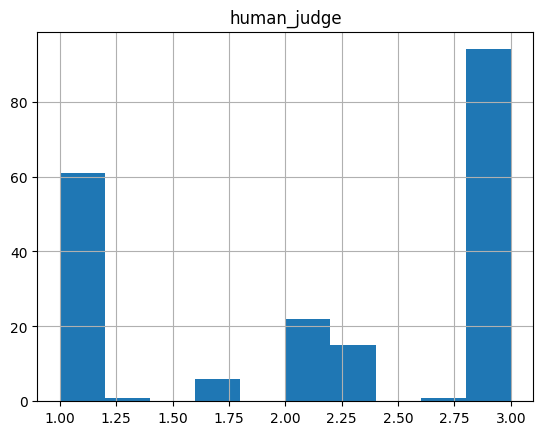

In [8]:
avg_score.hist()
pass

## Prepare the data

In [26]:
base = Path(".").resolve() / "eval-all" / "llm_judge_human_reference"
assert base.is_dir() and base.exists()
base


PosixPath('/workspaces/ts-qa/eval-all/llm_judge_human_reference')

In [42]:
# df = pd.read_hdf(base / "llmjudge_eval_set.h5", key="data")
eval_set = pd.read_csv(base / "llmjudge_eval_set.csv").drop(columns=["Unnamed: 0"])
eval_set = eval_set.join(avg_score, on=avg_score.index.names)
eval_set


,setting,model,mode,sample_id,question_id,prediction_text,action_sequence,textual_description,question_type,question,answer_type,answer_text,human_judge
0,4.2.2,Llama 2 (8B),full,25275,0,sitting down,"{'start': array([ 0., 4., 8., 12.], dtype=float32), 'end': array([ 4., 8., 12., 16.], dtype=float32), 'action': array(['sitting down', 'sitting down', 'sitting down',\n 'golfing (swinging a club)'], dtype=object), 'action_sentence': array(['The first activity the person is doing is sitting down',\n 'The person is engaging in sitting down',\n 'The activity sitting down can ...","The first activity the person is doing is sitting down. This action is starting at 0:0.0 and happens until 0:4.0, meaning the engagement in this is for 4.0 seconds. The person is engaging in sitting down from 0:4.0 to 0:8.0 (4.0 seconds total). The activity sitting down can be observed. This is happening from 0:8.0 to 0:12.0, which means for a total time of 4.0 seconds. The finishing action of...",comparison_counting_open,"Among the actions, which one shares the same frequency of occurrence as sitting down?",open,The correct answer is golfing (swinging a club).,1.000000
1,4.2.2,Gemma 2 (2B),full,25247,2,bowing,"{'start': array([ 0., 4., 8., 12.], dtype=float32), 'end': array([ 4., 8., 12., 16.], dtype=float32), 'action': array(['bowing', 'bowing', 'kicking a ball', 'skipping rope'],\n dtype=object), 'action_sentence': array(['The person is starting off the sequence with bowing',\n 'The person is engaging in bowing',\n 'The activity kicking a ball can be observed',\n 'The las...","The person is starting off the sequence with bowing at timestamp 0:0.0 and ending at 0:4.0, resulting in a total time of 4.0 seconds. The person is engaging in bowing. This action is starting at 0:4.0 and happens until 0:8.0, meaning the engagement in this is for 4.0 seconds. The activity kicking a ball can be observed. It is starting at second 0:8.0 and continuing until 0:12.0, so the person ...",before_open,"Before engaging in kicking a ball, what happened some time previously?",open,Someone is bowing.,3.000000
2,4.2.1,Falcon 2 (11B),350,27520,1,"running, sitting down, and holding a baby.","{'start': array([ 0., 4., 8., 12.], dtype=float32), 'end': array([ 4., 8., 12., 16.], dtype=float32), 'action': array(['running', 'sitting down', 'running', 'holding a baby'],\n dtype=object), 'action_sentence': array(['The person is starting off the sequence with running',\n 'The person is performing sitting down',\n 'The person is performing running',\n 'The person ...","The person is starting off the sequence with running. It is starting at second 0:0.0 and continuing until 0:4.0, so the person is doing this for 4.0 seconds. The person is performing sitting down from 0:4.0 to 0:8.0 (for 4.0 seconds). The person is performing running. This action is starting at 0:8.0 and happens until 0:12.0, meaning the engagement in this is for 4.0 seconds. The person is ter...",first_open,Which action did the person perform as the first action?,open,Someone is running.,1.666667
3,4.2.2,MVP,full,27562,1,2,"{'start': array([ 0., 4., 8., 12.], dtype=float32), 'end': array([ 4., 8., 12., 16.], dtype=float32), 'action': array(['drinking with the left hand', 'jumping once', 'running',\n 'drinking with the left hand'], dtype=object), 'action_sentence': array(['The first activity the person is doing is drinking with the left hand',\n 'The activity is jumping once',\n 'The activity ...","The first activity the person is doing is drinking with the left hand from 0:0.0 to 0:4.0 (for 4.0 seconds). The activity is jumping once. This action is starting at 0:4.0 and happens until 0:8.0, meaning the engagement in this is for 4.0 seconds. The activity running can be observed from 0:8.0 to 0:12.0 (4.0 seconds total). As a last action, the person is drinking with the left hand from 0:12...",interval_part_sequence_open,"From 1.756 until 6.515, what is the total number of distinct actions the person engages in?",open,2,2.333

In [43]:
# Duplicate the dataframe for performance testing
# eval_set = pd.concat([eval_set] * 5, ignore_index=True)
# eval_set.shape

## Setup LLM backend

In [46]:
from pandarallel import pandarallel

pandarallel.initialize(nb_workers=32, progress_bar=True, verbose=1)

In [47]:
# repo_id = "meta-llama/Llama-3.2-3B-Instruct"
# repo_id = "google/gemma-3-4b-it"
# repo_id = "/common-repos/Qwen2.5-14B-Instruct/Qwen2.5-14B-Instruct"
# print(
#     f'Run:\n\npython -m sglang.launch_server --model-path {repo_id} --port 30000 --host 0.0.0.0\n\n... and wait for "The server is fired up and ready to roll!" to appear.'
# )

In [48]:
set_default_backend(RuntimeEndpoint("http://docker-ts-qa-sg-run-5ba9c8d702c6:30000"))

## The judge

In [52]:
JUDGE_PROMPT_TEMPLATE = """You will be given a scene_description with timesamps and a scene_question regarding that scene. You will also be given a reference_answer and system_answer couple.
Your task is to provide a TotalRating scoring how well the system_answer answers the user concerns expressed in the scene_question. The reference_answer is provided as reference for a very good answer.
Give your answer on a scale of 1 to 3, where 1 means that the system_answer is not helpful at all, and 3 means that the system_answer completely and helpfully addresses the scene_question.
You will also provide a brief rationale for your rating.

Here is the scale you should use to build your answer:
1: The system_answer is terrible: the answer is factually incorrect or corrupt in some way (e.g., empty or nonsensical)
2: The system_answer is bad: somewhat correctly answers the scene_question like the reference_answer, yet contains additional useless/ambiguous/wrong information or is incomplete
3: The system_answer is good: correctly answers the scene_question and is helpful in the context of the scene

Provide your feedback in the following JSON format:
{{
    "BriefRationale:": "<your rationale, at most 3 sentences>",
    "TotalRating:": <your rating>
}}

You MUST provide values for "BriefRationale" and "TotalRating" in your answer.
Do NOT respond with any other text in your answer.
Immediately, start with the JSON object, without any additional text or explanation.

Now here are the question and answer:

- scene_description: {scene_description}
- scene_question: {scene_question}
- reference_answer: {reference_answer}
- system_answer: {system_answer}

Provide your feedback. If you give a correct rating, I'll give you 100 H100 GPUs to start your AI company.
"""


max_rationale = 500


class JudgePrompt(BaseModel):
    BriefRationale: str = Field(
        ..., max_length=max_rationale, description="Your rationale, at most 3 sentences"
    )
    TotalRating: Literal[1, 2, 3] = Field(
        ...,
        description="Your rating on a scale of 1 to 3",
    )


@function
def sglang_llm_judge(s, row):
    # scene_description = TODO make table from this
    scene_description = row["textual_description"]
    s += user(
        JUDGE_PROMPT_TEMPLATE.format(
            scene_description=scene_description,
            scene_question=row["question"],
            reference_answer=row["answer_text"],
            system_answer=row["prediction_text"],
        )
    )
    s += assistant(
        gen(
            "response",
            max_tokens=max_rationale + 100,
            temperature=0,
            # json_schema=JudgePrompt.model_json_schema(),
        )
    )


df = eval_set.copy()
df["llm_judge_raw"] = df.parallel_apply(
    lambda x: (
        x["llm_judge_raw"]
        if "llm_judge_raw" in x and x["llm_judge_raw"] != pd.NA
        else sglang_llm_judge.run(
            row=x,
            # temperature=0.7,
            # top_p=0.8,
            # presence_penalty=1.5,
        )["response"]
    ),
    axis=1,
)


def decode(response) -> dict[str, Any]:
    try:
        return json.loads(response)
    except json.JSONDecodeError:
        print(f"Failed to decode response: {response}")
        return dict(BriefRationale=pd.NA, TotalRating=pd.NA)


df[["llm_judge_rationale", "llm_judge_score"]] = (
    df["llm_judge_raw"]
    .apply(decode)
    .apply(pd.Series)[["BriefRationale", "TotalRating"]]
)

Failed to decode response: 	A:
Okay, let's tackle this. The user is asking which action has the same frequency as sitting down. First, I need to understand the scene description. 

Looking at the timestamps, sitting down happens three times: from 0:0.0-0:4.0, 0:4.0-0:8.0, and 0:8.0-0:12.0. Each instance is 4 seconds, so three occurrences. Then, the finishing action is golfing (swinging a club) from 0:12.0-0:16.0, which is one occurrence. Wait, but the question is about frequency. If sitting down occurs three times and golfing once, then the answer should be golfing? Wait, maybe I'm misunderstanding. Wait, the user says "frequency of occurrence" – so how many times each action occurs. 

Wait, the scene description says the person is sitting down three times, each 4 seconds. Then golfing once. So sitting down occurs three times, golfing once. So the answer should be golfing? But the reference answer says golfing is the correct answer. Wait, but the system answer just says "sitting down".

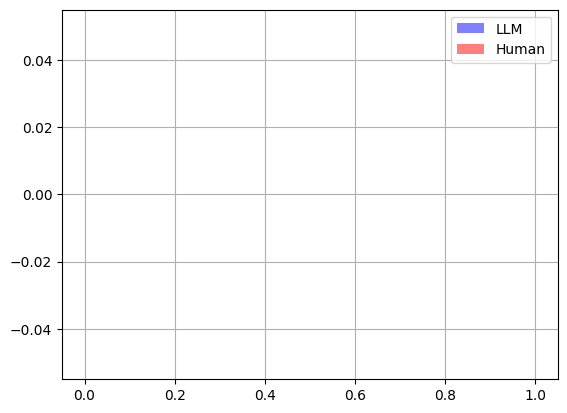

In [ ]:
df_not_na = df.dropna(subset=["llm_judge_score"]).astype({"llm_judge_score": float})

# Plot both histrograms in one plot
df_not_na["llm_judge_score"].hist(alpha=0.5, color="blue", label="LLM")
df_not_na["human_judge"].hist(alpha=0.5, color="red", label="Human")
plt.legend()
pass

In [51]:
print("Correlation between LLM-as-a-judge and the human raters:")
print(
    f"Mean difference: {(df_not_na['llm_judge_score'] - df_not_na['human_judge']).abs().mean():.3f}"
)
print(f"Peason: {df['llm_judge_score'].corr(df['human_judge'], method='pearson'):.3f}")
print(
    f"Spearman: {df['llm_judge_score'].corr(df['human_judge'], method='spearman'):.3f}"
)
print(f"Kendall: {df['llm_judge_score'].corr(df['human_judge'], method='kendall'):.3f}")


Correlation between LLM-as-a-judge and the human raters:
Mean difference: nan
Peason: nan
Spearman: nan
Kendall: nan
